# Honest-mean tail-variant preliminary vetting — v2000 (2000–2023 (year≥2000 filter of the full data))

Results: `02-evaluate/20260722_v2000_tailvariants/dh_results.parquet` (coupled preliminary, `--skip-model-predictions`).

**Honest tail families** (median-reporting gpd/weibull/log_logistic dropped): already-mean `gamma`/`lognormal`/`truncated_normal`; D `weibull_mean`; C `gpd_cens`/`log_logistic_cens`; B `gpd_trunc`/`log_logistic_trunc`; A `gpd_shadow`/`log_logistic_shadow`; count `nb`/`poisson`.

Slice-wise vetting — OOS score selects, not these views. `pred_obs_ratio` is now an honest expectation, so the median-era calibration gate has been widened (tune for this run).


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from idd_tc_mortality.viz import screening as H

In [2]:
ROOT      = Path('/mnt/team/idd/pub/idd_tc_mortality')
INPUT_DATE = '20260722_v2000'   # 00-data vintage (2000–2023 (year≥2000 filter of the full data))
INPUT_PATH = ROOT / '00-data' / INPUT_DATE / 'input.parquet'

obs = pd.read_parquet(INPUT_PATH)

print(f'rows:               {len(obs):,}')
print(f'unique storms:      {obs["storm_id"].nunique():,}')
print(f'unique admins:      {obs["location_id"].nunique():,}')
print(f'years:              {int(obs["year"].min())} – {int(obs["year"].max())}')
print(f'total deaths:       {int(obs["deaths"].sum()):,}')
print(f'rows by basin:      {obs.groupby("basin")["storm_id"].nunique().sort_values(ascending=False).to_dict()}')
print(f'mean exposed/row:   {obs["exposed"].mean():,.0f}')
print(f'median exposed/row: {obs["exposed"].median():,.0f}')


rows:               1,903
unique storms:      997
unique admins:      88
years:              2000 – 2023
total deaths:       186,038
rows by basin:      {'WP': 405, 'NA': 205, 'AU': 183, 'NI': 119, 'SI': 71, 'SP': 10, 'EP': 4}
mean exposed/row:   75,318,182
median exposed/row: 2,552,969


**Read this section before judging the screening metrics:**

- A high concentration (top 5 storms ≥ 80% of deaths) means `full_pred_obs_ratio_oos`
  is effectively a function of how well the model handles those 5 storms — not
  a general calibration metric. The `[0.9, 1.1]` gate is then primarily a
  "did the model get Nargis right" filter.
- The same concentration justifies the `drop-top-N storms` variant of the
  screening ratio: if we want a metric sensitive to bulk-of-storms behaviour,
  we have to remove the events the aggregate is dominated by.
- For the time-series metrics: years dominated by mega-events drive the OLS
  regression. A correlation of 0.18 may be a Nargis/Haiyan artifact, not a
  model property — same drop-top-N logic applies (drop top-N years before
  computing `cor_ts_oos`).


## Setup

Load the evaluate run, median-aggregate IS and OOS metrics per
configuration, apply the calibration gate
(`full_pred_obs_ratio_oos ∈ [0.9, 1.1]`), and initialise the cumulative
screening mask. `df` holds the calibrated DH configs; `df_all` keeps
the pre-filter set for reference.

In [3]:
ROOT      = Path('/mnt/team/idd/pub/idd_tc_mortality')
RESULTS_DIR = '20260722_v2000_tailvariants'   # 02-evaluate (in-memory re-fit, 360 tasks)
RESULTS_PATH = ROOT / '02-evaluate' / RESULTS_DIR / 'dh_results.parquet'
print(RESULTS_PATH)

df_all = H.load_and_aggregate(RESULTS_PATH)
print(f'{len(df_all):,} configurations loaded across '
      f'{df_all["threshold_quantile"].nunique()} thresholds')

/mnt/team/idd/pub/idd_tc_mortality/02-evaluate/20260722_v2000_tailvariants/dh_results.parquet
224,640 configurations loaded across 6 thresholds


In [4]:
# Calibration gate: Because tail storms are rare, we expect to under-predict total deaths.
# Culling models that are WAY too low or too high

RATIO_BOUNDS = (0.05, 10.0)  # widened from (0.05, 1.1): honest-mean tails shift
                             # pred_obs_ratio up vs the median era; tune for this run
ratio      = df_all['full_pred_obs_ratio_oos']
calibrated = ratio.between(*RATIO_BOUNDS) & ratio.notna()
df = df_all[calibrated].reset_index(drop=True)
print(f'{len(df):,} configs ({len(df)/len(df_all):.1%}) pass '
      f'full_pred_obs_ratio_oos in [{RATIO_BOUNDS[0]}, {RATIO_BOUNDS[1]}]')
# How many were too small
too_small = ratio < RATIO_BOUNDS[0]
print(f'{too_small.sum():,} configs ({too_small.mean():.1%}) are too small')
# How many were too large
too_large = ratio > RATIO_BOUNDS[1]
print(f'{too_large.sum():,} configs ({too_large.mean():.1%}) are too large')

131,309 configs (58.5%) pass full_pred_obs_ratio_oos in [0.05, 10.0]
0 configs (0.0%) are too small
89,011 configs (39.6%) are too large


In [5]:
# Cumulative screening mask: True = config still in consideration.
screen = pd.Series(True, index=df.index)

def remaining(label: str) -> None:
    n = int(screen.sum())
    per_thr = df.loc[screen, 'threshold_quantile'].value_counts().sort_index()
    print(f'{label}: {n:,} configs '
          f'({per_thr.to_dict()})')

remaining('Start')

Start: 131,309 configs ({0.7: 23082, 0.75: 25090, 0.7999999999999999: 22871, 0.85: 19023, 0.8999999999999999: 21099, 0.95: 20144})


587 unique (tail spec × threshold) combinations


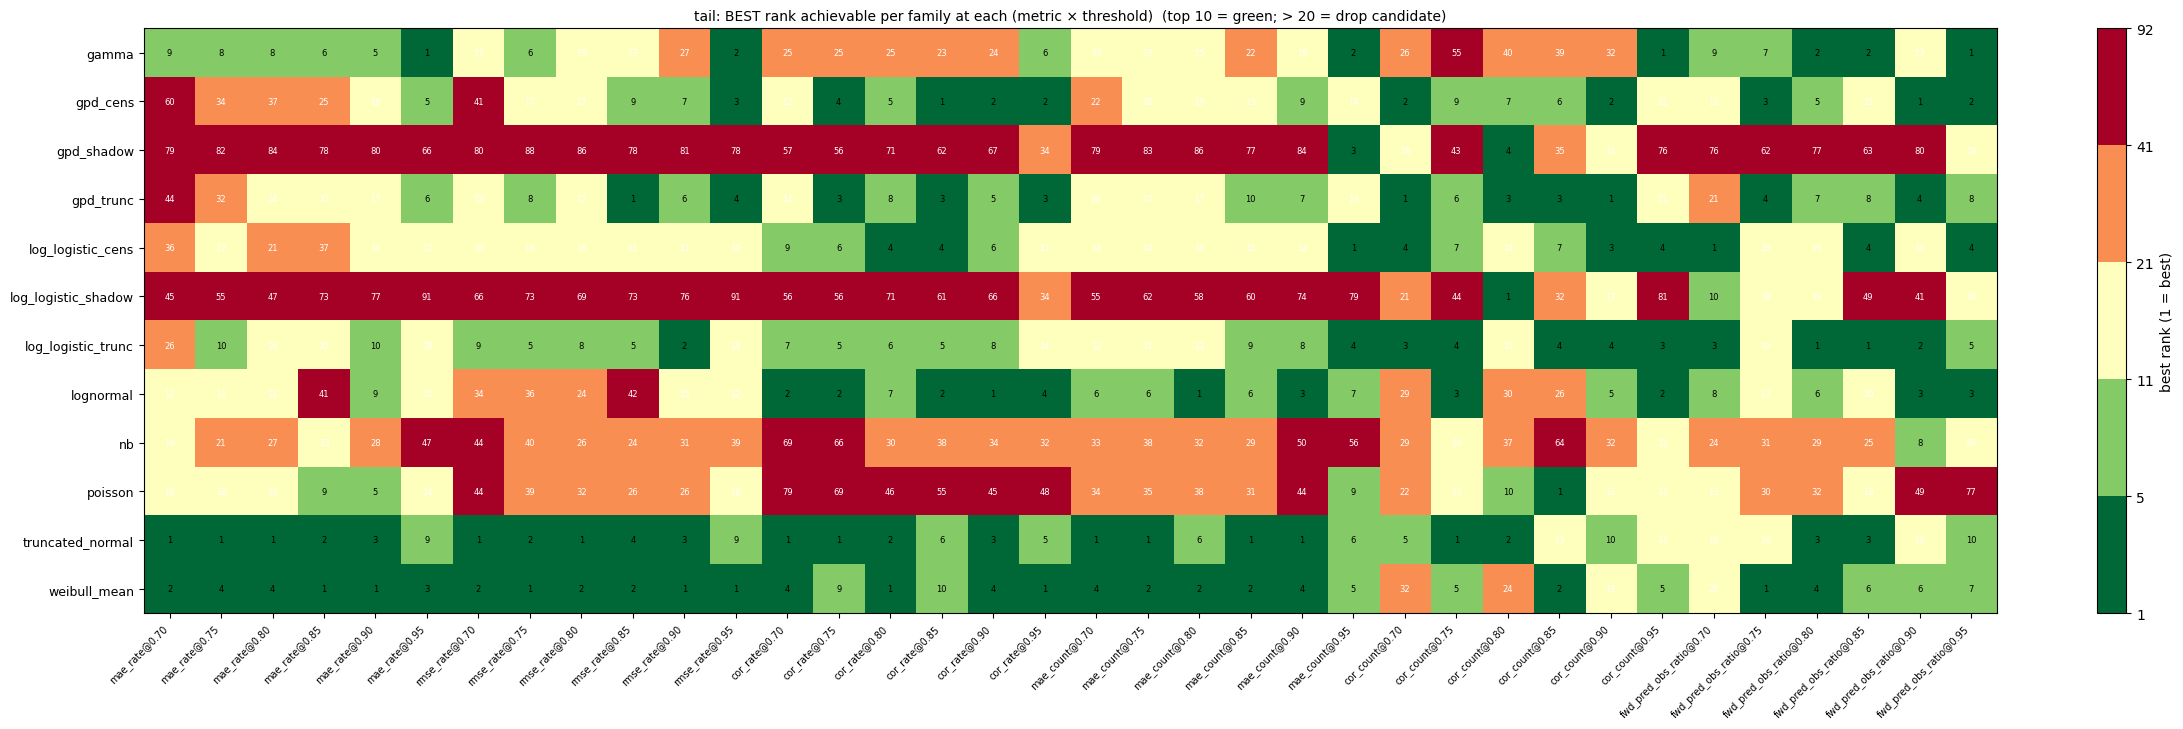

In [6]:
tail_df = H.dedup_for_stage(df, 'tail')
print(f'{len(tail_df):,} unique (tail spec × threshold) combinations')

# fwd_pred_obs_ratio_oos is assembled (varies across s1/s2/bulk) — aggregate per tail spec.
TAIL_KEYS = ['tail_family', 'tail_exposure_mode', 'tail_cov', 'threshold_quantile']
fwd = df.groupby(TAIL_KEYS)['fwd_pred_obs_ratio_oos'].median().reset_index()
tail_df = tail_df.merge(fwd, on=TAIL_KEYS, how='left')

TAIL_METRICS = ['tail_mae_rate_oos', 'tail_rmse_rate_oos', 'tail_cor_rate_oos',
                'tail_mae_count_oos', 'tail_cor_count_oos', 'fwd_pred_obs_ratio_oos']
TAIL_DIR = {'tail_mae_rate_oos': 'lower', 'tail_rmse_rate_oos': 'lower',
            'tail_cor_rate_oos': 'higher', 'tail_mae_count_oos': 'lower',
            'tail_cor_count_oos': 'higher', 'fwd_pred_obs_ratio_oos': 'calib'}
H.family_attainability_heatmap(tail_df, 'tail', TAIL_METRICS,
                               metric_directions=TAIL_DIR, top_n=10, drop_threshold=20)
plt.show()


## S1 — P(deaths >= 1)

S1 is threshold-independent: the binary outcome `any_death` does not
shift with `threshold_quantile`, so the same `(s1_family, s1_exposure_mode,
s1_cov)` triple yields identical S1 metrics across every DH config that
uses it. Deduplicate to one row per triple before plotting.

In [7]:
remaining('S1 start')

S1 start: 131,309 configs ({0.7: 23082, 0.75: 25090, 0.7999999999999999: 22871, 0.85: 19023, 0.8999999999999999: 21099, 0.95: 20144})


15 unique S1 specs


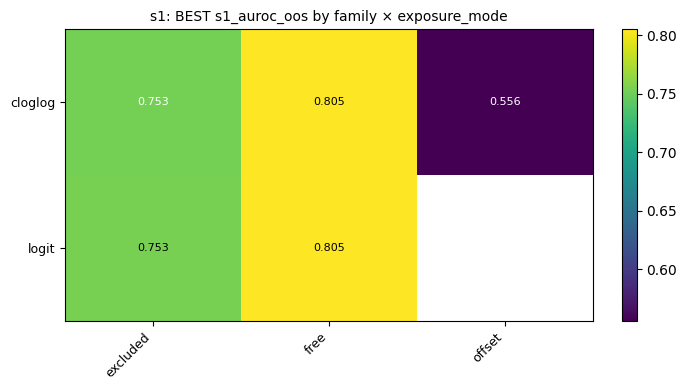

In [8]:
s1_df = H.dedup_for_stage(df, 's1')
print(f'{len(s1_df):,} unique S1 specs')

H.plot_stage_heatmap(s1_df, 's1', 's1_auroc_oos',
                     lower_better=False, log_scale=False,
                     facet_by_threshold=False)
plt.show()

In [9]:
# Numeric: best s1_auroc_oos per (family × exposure_mode).
print(H._family_exposure_pivot(s1_df, 's1', 's1_auroc_oos',
                                lower_better=False).round(4))

s1_exposure_mode  excluded    free  offset
s1_family                                 
cloglog             0.7530  0.8049  0.5559
logit               0.7534  0.8047     NaN


**Decision — S1.** Keep `s1_family = logit` and `s1_exposure_mode = free`.
`cloglog` ties `logit` to within ~0.001 AUROC, `excluded` drops to 0.72,
`offset` collapses to 0.58. Drop `cloglog`, `excluded`, and `offset`.

In [10]:
s1_keep = (df['s1_family'] == 'logit') & (df['s1_exposure_mode'] == 'free')
screen &= s1_keep
remaining('S1 end')

S1 end: 25,626 configs ({0.7: 4405, 0.75: 4734, 0.7999999999999999: 4440, 0.85: 3889, 0.8999999999999999: 4252, 0.95: 3906})


## S2 — P(rate >= threshold | deaths >= 1)

S2's binary outcome shifts with threshold, so dedup per
`(s2_family, s2_exposure_mode, s2_cov, threshold_quantile)` and facet by
threshold. The S2 plane is independent of the S1 / bulk / tail specs,
so the heatmap is the same regardless of the prior screening; the model
count, however, is cumulative.

In [11]:
remaining('S2 start')

S2 start: 25,626 configs ({0.7: 4405, 0.75: 4734, 0.7999999999999999: 4440, 0.85: 3889, 0.8999999999999999: 4252, 0.95: 3906})


72 unique (S2 spec × threshold) combinations


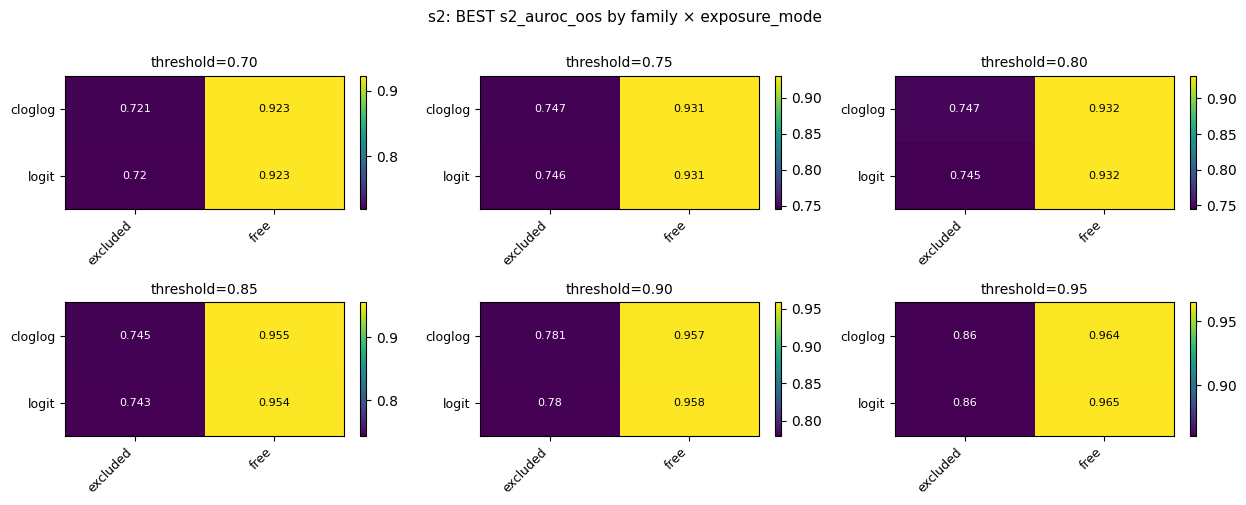

In [12]:
s2_df = H.dedup_for_stage(df, 's2')
print(f'{len(s2_df):,} unique (S2 spec × threshold) combinations')

H.plot_stage_heatmap(s2_df, 's2', 's2_auroc_oos',
                     lower_better=False, log_scale=False,
                     facet_by_threshold=True)
plt.show()

In [13]:
# Numeric: best s2_auroc_oos per (family × exposure_mode) per threshold.
for thr in sorted(s2_df['threshold_quantile'].dropna().unique()):
    chunk = s2_df[s2_df['threshold_quantile'] == thr]
    print(f'--- threshold={thr:.2f} ---')
    print(H._family_exposure_pivot(chunk, 's2', 's2_auroc_oos',
                                    lower_better=False).round(4))
    print()

--- threshold=0.70 ---
s2_exposure_mode  excluded    free
s2_family                         
cloglog             0.7212  0.9230
logit               0.7198  0.9228

--- threshold=0.75 ---
s2_exposure_mode  excluded    free
s2_family                         
cloglog             0.7467  0.9307
logit               0.7455  0.9307

--- threshold=0.80 ---
s2_exposure_mode  excluded    free
s2_family                         
cloglog             0.7475  0.9317
logit               0.7448  0.9321

--- threshold=0.85 ---
s2_exposure_mode  excluded    free
s2_family                         
cloglog             0.7450  0.9550
logit               0.7434  0.9541

--- threshold=0.90 ---
s2_exposure_mode  excluded    free
s2_family                         
cloglog             0.7807  0.9572
logit               0.7799  0.9582

--- threshold=0.95 ---
s2_exposure_mode  excluded    free
s2_family                         
cloglog             0.8602  0.9639
logit               0.8602  0.9646



**Decision — S2.** Keep `s2_family = logit` and `s2_exposure_mode = free`
at every threshold. `logit` and `cloglog` agree within ~0.001 AUROC in
every comparable cell; `free` dominates `excluded` by 0.10–0.15 AUROC,
widening at higher thresholds. Drop `cloglog` and `excluded`.

In [14]:
s2_keep = (df['s2_family'] == 'logit') & (df['s2_exposure_mode'] == 'free')
screen &= s2_keep
remaining('S2 end')

S2 end: 10,248 configs ({0.7: 1656, 0.75: 1746, 0.7999999999999999: 1744, 0.85: 1599, 0.8999999999999999: 1758, 0.95: 1745})


## Bulk — E[rate | deaths >= 1, rate < threshold]

Bulk is doubly threshold-dependent: training set and eval set both
shift with threshold, so absolute-error metrics (`mae_rate`, `rmse_rate`,
`mae_count`) are *not* comparable across threshold columns of the same
panel. Read within a panel; use ranks / Kendall τ for cross-threshold
stability checks.

### Family choice

In [15]:
remaining('Bulk start')

Bulk start: 10,248 configs ({0.7: 1656, 0.75: 1746, 0.7999999999999999: 1744, 0.85: 1599, 0.8999999999999999: 1758, 0.95: 1745})


324 unique (bulk spec × threshold) combinations


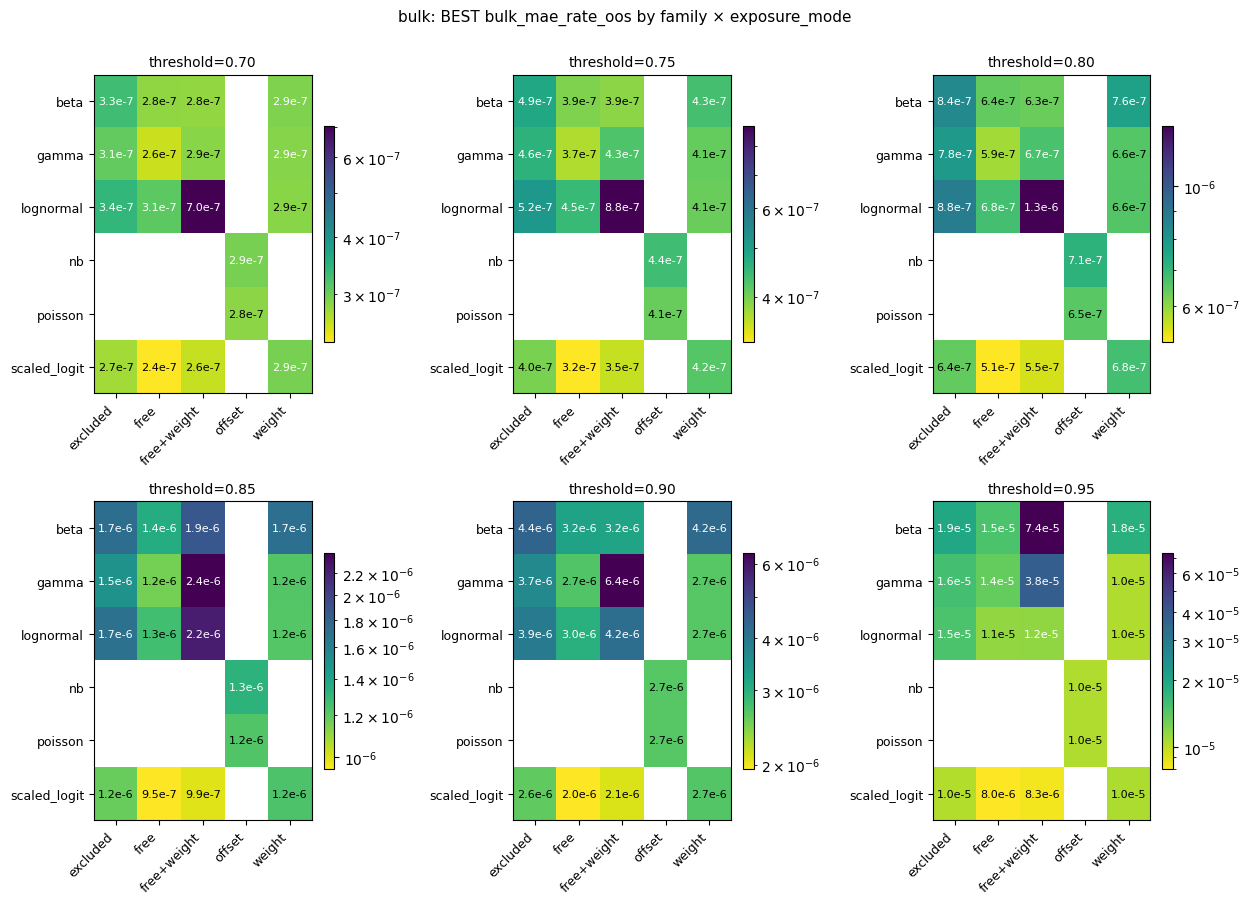

In [16]:
bulk_df = H.dedup_for_stage(df, 'bulk')
print(f'{len(bulk_df):,} unique (bulk spec × threshold) combinations')

H.plot_stage_heatmap(bulk_df, 'bulk', 'bulk_mae_rate_oos',
                     lower_better=True, log_scale=True,
                     facet_by_threshold=True)
plt.show()

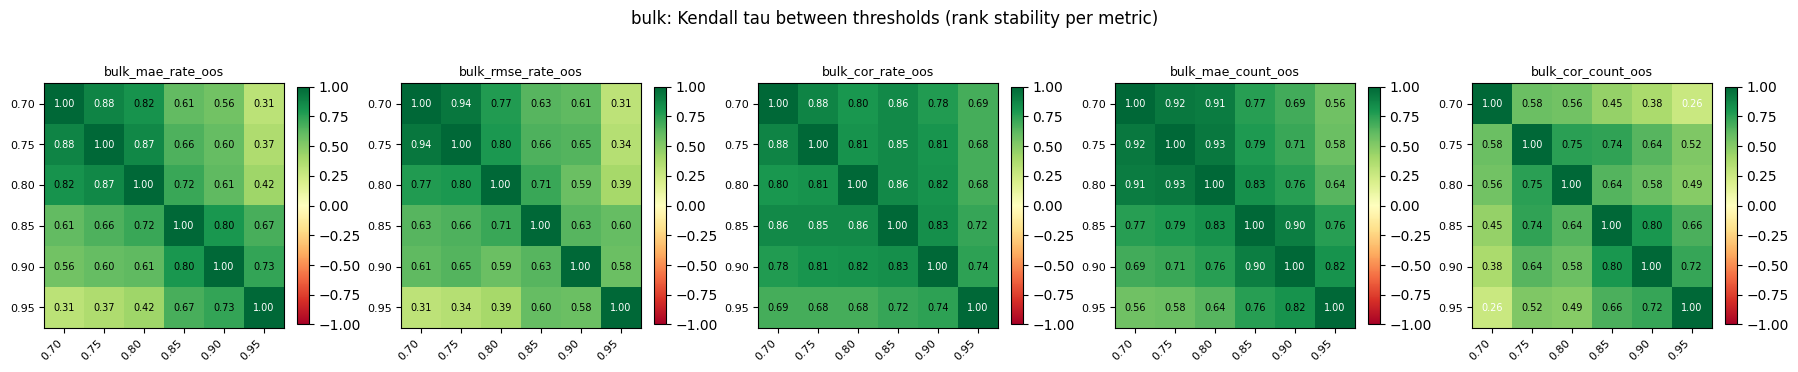

In [17]:
# Cross-threshold rank stability: high τ → family decision transfers across thresholds.
BULK_METRICS = [
    'bulk_mae_rate_oos', 'bulk_rmse_rate_oos', 'bulk_cor_rate_oos',
    'bulk_mae_count_oos', 'bulk_cor_count_oos',
]
BULK_DIR = {
    'bulk_mae_rate_oos':  'lower',
    'bulk_rmse_rate_oos': 'lower',
    'bulk_cor_rate_oos':  'higher',
    'bulk_mae_count_oos': 'lower',
    'bulk_cor_count_oos': 'higher',
}
H.kendall_threshold_heatmap(bulk_df, 'bulk', BULK_METRICS,
                            metric_directions=BULK_DIR)
plt.show()

**Decision — Bulk family.** Keep `bulk_family = scaled_logit` —
both enforce `predicted_rate ∈ (0, threshold)` by construction. Drop
`gamma`, `lognormal`, `nb`, `poisson`, `beta`. 

In [18]:
bulk_fam_keep = df['bulk_family'].isin(['scaled_logit'])
screen &= bulk_fam_keep
remaining('Bulk after family decision')

Bulk after family decision: 2,304 configs ({0.7: 368, 0.75: 388, 0.7999999999999999: 388, 0.85: 356, 0.8999999999999999: 392, 0.95: 412})


### Exposure mode

With family narrowed to `scaled_logit`, re-examine the
`exposure_mode` plane.

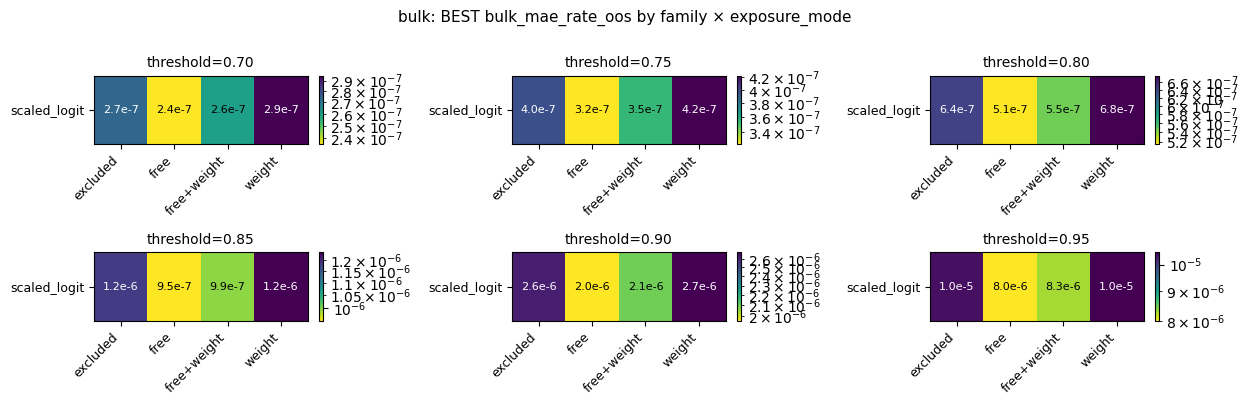

In [19]:
bulk_focus_df = bulk_df[bulk_df['bulk_family'].isin(['scaled_logit'])].copy()
H.plot_stage_heatmap(bulk_focus_df, 'bulk', 'bulk_mae_rate_oos',
                     lower_better=True, log_scale=True,
                     facet_by_threshold=True)
plt.show()

**Decision — Bulk exposure mode.** Keep `bulk_exposure_mode ∈ {free,
free+weight}` for both surviving families. Drop `excluded` and `weight`.
The choice between `free` and `free+weight` is a downstream calibration
question, not a screening one.

In [20]:
bulk_exp_keep = df['bulk_exposure_mode'].isin(['free', 'free+weight'])
screen &= bulk_exp_keep
remaining('Bulk end')

Bulk end: 1,152 configs ({0.7: 184, 0.75: 194, 0.7999999999999999: 194, 0.85: 178, 0.8999999999999999: 196, 0.95: 206})


## Tail — E[rate | deaths >= 1, rate >= threshold]

Tail has more families and noisier cross-threshold rankings than bulk
(adjacent-threshold Kendall τ around 0.4–0.5 in count metrics). The
cleanest screening question is therefore *attainability*: which
families have at least one (cov × exposure_mode) combination that
reaches the top of the rankings at each (metric × threshold) cell?

In [21]:
remaining('Tail start')

Tail start: 1,152 configs ({0.7: 184, 0.75: 194, 0.7999999999999999: 194, 0.85: 178, 0.8999999999999999: 196, 0.95: 206})


In [22]:
[c for c in df.columns if 'fwd' in c]

['fwd_mae_rate',
 'fwd_rmse_rate',
 'fwd_pred_obs_ratio',
 'fwd_coverage_rate_1',
 'fwd_coverage_count_1',
 'fwd_coverage_rate_2',
 'fwd_coverage_count_2',
 'fwd_coverage_rate_3',
 'fwd_coverage_count_3',
 'fwd_coverage_rate_4',
 'fwd_coverage_count_4',
 'fwd_coverage_rate_5',
 'fwd_coverage_count_5',
 'fwd_coverage_rate_6',
 'fwd_coverage_count_6',
 'fwd_coverage_rate_7',
 'fwd_coverage_count_7',
 'fwd_coverage_rate_8',
 'fwd_coverage_count_8',
 'fwd_coverage_rate_9',
 'fwd_coverage_count_9',
 'fwd_coverage_rate_10',
 'fwd_coverage_count_10',
 'fwd_coverage_rate_11',
 'fwd_coverage_count_11',
 'fwd_coverage_rate_12',
 'fwd_coverage_count_12',
 'fwd_coverage_rate_13',
 'fwd_coverage_count_13',
 'fwd_coverage_rate_14',
 'fwd_coverage_count_14',
 'fwd_coverage_rate_15',
 'fwd_coverage_count_15',
 'fwd_coverage_rate_16',
 'fwd_coverage_count_16',
 'fwd_coverage_rate_17',
 'fwd_coverage_count_17',
 'fwd_coverage_rate_18',
 'fwd_coverage_count_18',
 'fwd_coverage_rate_19',
 'fwd_coverage_co

587 unique (tail spec × threshold) combinations


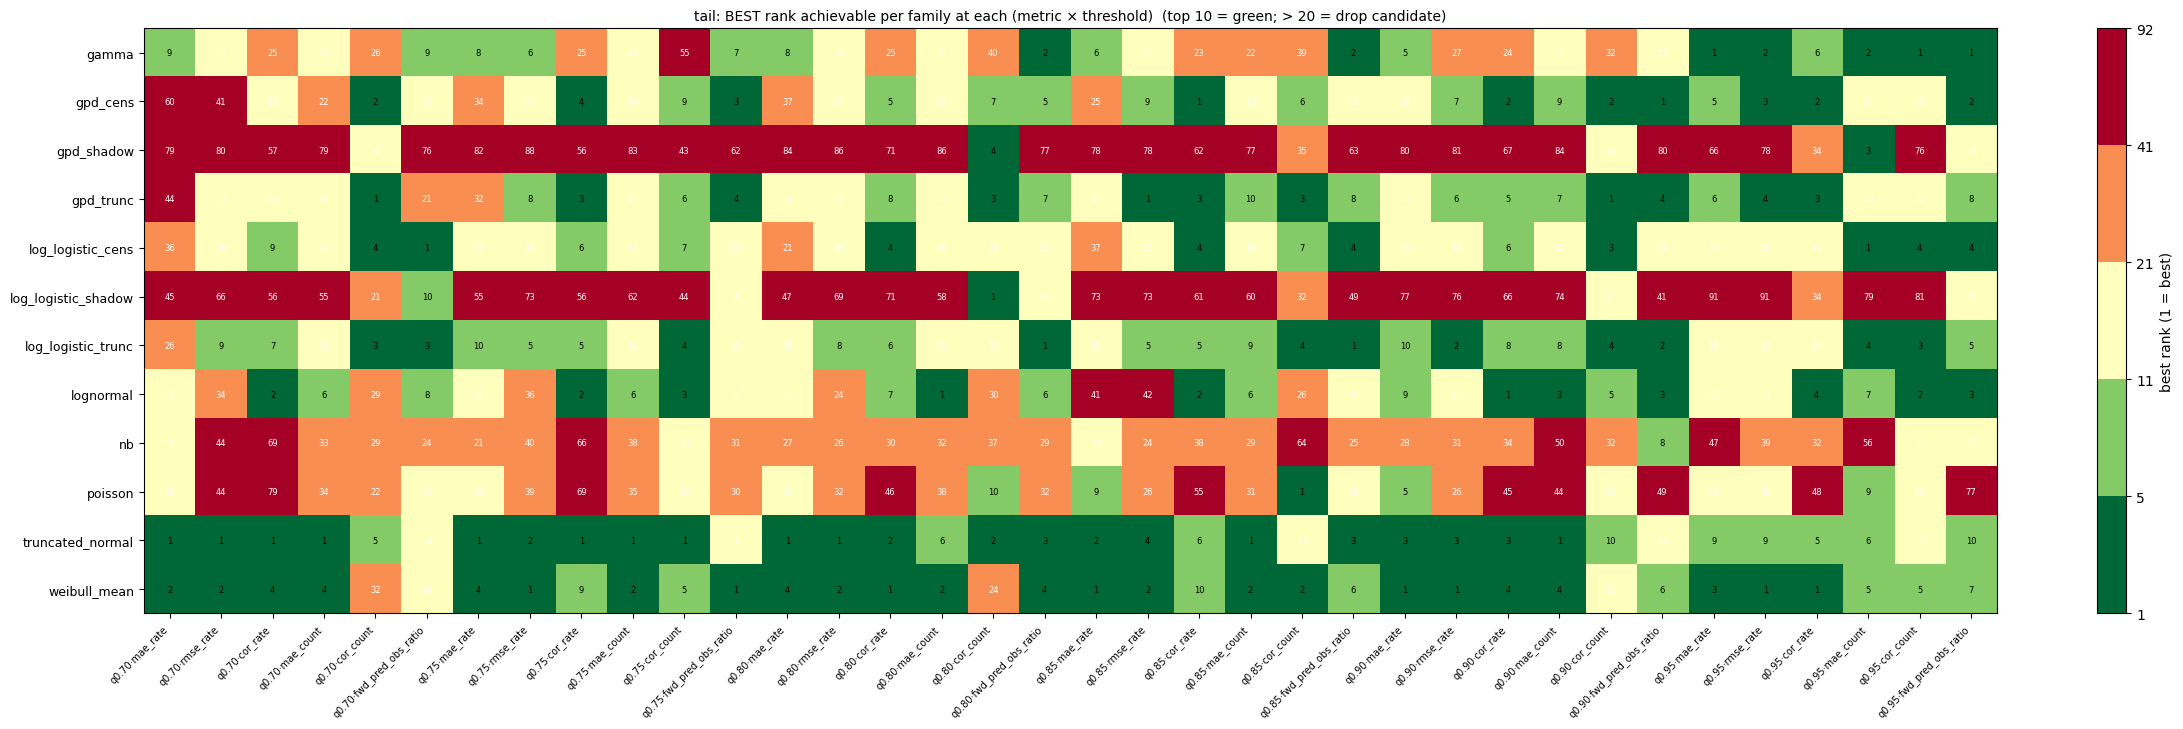

In [23]:
tail_df = H.dedup_for_stage(df, 'tail')
print(f'{len(tail_df):,} unique (tail spec × threshold) combinations')

# fwd_pred_obs_ratio_oos is assembled (varies across s1/s2/bulk) — aggregate per tail spec.
TAIL_KEYS = ['tail_family', 'tail_exposure_mode', 'tail_cov', 'threshold_quantile']
fwd = df.groupby(TAIL_KEYS)['fwd_pred_obs_ratio_oos'].median().reset_index()
tail_df = tail_df.merge(fwd, on=TAIL_KEYS, how='left')

TAIL_METRICS = ['tail_mae_rate_oos', 'tail_rmse_rate_oos', 'tail_cor_rate_oos',
                'tail_mae_count_oos', 'tail_cor_count_oos', 'fwd_pred_obs_ratio_oos']
TAIL_DIR = {'tail_mae_rate_oos': 'lower', 'tail_rmse_rate_oos': 'lower',
            'tail_cor_rate_oos': 'higher', 'tail_mae_count_oos': 'lower',
            'tail_cor_count_oos': 'higher', 'fwd_pred_obs_ratio_oos': 'calib'}
H.family_attainability_heatmap(tail_df, 'tail', TAIL_METRICS,
                               metric_directions=TAIL_DIR, top_n=10, drop_threshold=20,col_order='threshold'
                               )

plt.show()


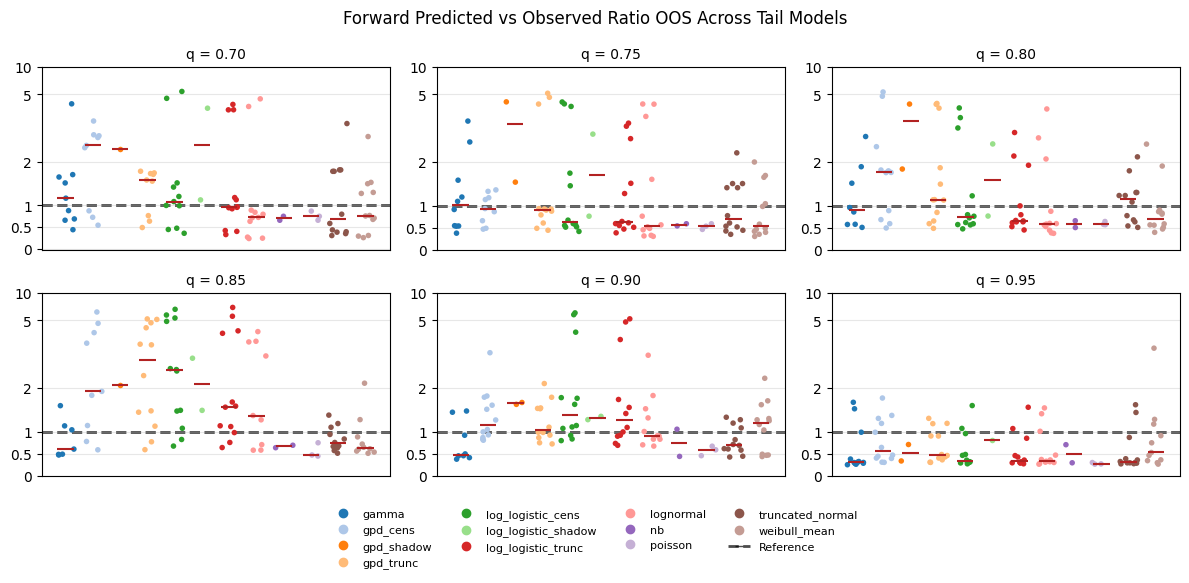

In [24]:
metric = 'fwd_pred_obs_ratio_oos'
metric_text = 'Forward Predicted vs Observed Ratio OOS'
metric_target = 1
metric_calib = True
metric_scale = 'symlog'

# Make a side-by-side beeswarm of mae_count@90 across tail models
import seaborn as sns
from matplotlib.lines import Line2D
import matplotlib.ticker as mticker
ratio_ticks = [0, 0.5, 1, 2, 5, 10]



# threshold_quantile carries float noise (0.8999999999999999), so match with isclose
thresholds = sorted(tail_df['threshold_quantile'].unique())
# Sort families by alphabetical order
# families = (tail_df.groupby('tail_family')[metric]
#                    .median().sort_values().index.tolist())
families = sorted(tail_df['tail_family'].unique())
palette = dict(zip(families, sns.color_palette('tab20', len(families))))
fig, axes = plt.subplots(2, 3, figsize=(12, 5))
axes = axes.flatten()
for i, threshold in enumerate(thresholds):
    ax = axes[i]
    sub_df = tail_df[np.isclose(tail_df['threshold_quantile'], threshold)]
    if metric_calib:
         sub_df['y'] = sub_df[metric] - metric_target
    else:
         sub_df['y'] = sub_df[metric]
    sub_med = sub_df.groupby('tail_family')['y'].median()
    sns.stripplot(data=sub_df, x='tail_family', y='y',
                order=families, hue='tail_family', palette=palette, size=4, ax=ax,
                jitter=0.35)
    ax.set_title(f'q = {threshold:.2f}', fontsize=10)
    if ax.get_legend():
            ax.get_legend().remove()   # replaced by one shared figure legend below
    for i, fam in enumerate(families):
        if fam in sub_med:
            ax.hlines(sub_med[fam], i - 0.3, i + 0.3, color='firebrick',
                    linewidth=1.5, zorder=5)
    # Draw a horizontal line at y=0 for reference and label it in the legend as "Reference"
    ax.axhline(0, color='black', linestyle='--', linewidth=2, alpha=0.7, zorder = -1)
    ax.set_yscale(metric_scale)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([])
    ax.set_yticks([r - 1 for r in ratio_ticks])          # positions in ratio-1 space
    ax.set_yticklabels([f'{r:g}' for r in ratio_ticks])
    ax.yaxis.set_minor_locator(mticker.NullLocator())     # drop the confusing default 10^0 ticks



    ax.grid(axis='y', alpha=0.3)
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
handles = [Line2D([], [], marker='o', linestyle='', color=palette[f], label=f)
           for f in families]
handles.append(Line2D([], [], marker='_', linestyle='--', color='black', label='Reference', linewidth=2, alpha=0.7))
fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 0.0),
           ncol=4, frameon=False, fontsize=8)
fig.suptitle(f'{metric_text} Across Tail Models', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
metric = 'fwd_pred_obs_ratio_oos'
metric_text = 'Forward Predicted vs Observed Ratio OOS'
metric_target = 1
metric_calib = False
metric_scale = 'log'

# Make a side-by-side beeswarm of mae_count@90 across tail models
import seaborn as sns
from matplotlib.lines import Line2D

# threshold_quantile carries float noise (0.8999999999999999), so match with isclose
thresholds = sorted(tail_df['threshold_quantile'].unique())
# Sort families by alphabetical order
# families = (tail_df.groupby('tail_family')[metric]
#                    .median().sort_values().index.tolist())
families = sorted(tail_df['tail_family'].unique())
palette = dict(zip(families, sns.color_palette('tab20', len(families))))
fig, axes = plt.subplots(2, 3, figsize=(12, 5))
axes = axes.flatten()
for i, threshold in enumerate(thresholds):
    ax = axes[i]
    sub_df = tail_df[np.isclose(tail_df['threshold_quantile'], threshold)]
    if metric_calib:
         sub_df['y'] = sub_df[metric] - metric_target
    else:
         sub_df['y'] = sub_df[metric]
    sub_med = sub_df.groupby('tail_family')['y'].median()
    sns.stripplot(data=sub_df, x='tail_family', y='y',
                order=families, hue='tail_family', palette=palette, size=4, ax=ax,
                jitter=0.35)
    ax.set_title(f'q = {threshold:.2f}', fontsize=10)
    if ax.get_legend():
            ax.get_legend().remove()   # replaced by one shared figure legend below
    for i, fam in enumerate(families):
        if fam in sub_med:
            ax.hlines(sub_med[fam], i - 0.3, i + 0.3, color='firebrick',
                    linewidth=1.5, zorder=5)
    ax.set_yscale(metric_scale)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([])

    ax.grid(axis='y', alpha=0.3)
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
handles = [Line2D([], [], marker='o', linestyle='', color=palette[f], label=f)
           for f in families]
fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 0.0),
           ncol=4, frameon=False, fontsize=8)
fig.suptitle(f'{metric_text} Across Tail Models', fontsize=12)

plt.tight_layout()
plt.show()

**Decision — Tail.** Drop `nb`, `poisson`, `log_logistic_shadow`, and `gpd_shadow` — best-rank-achievable is
> 20 in nearly every cell, and structurally they have no threshold
awareness. Keep all others

In [25]:
tail_keep = ~df['tail_family'].isin(['nb', 'poisson', 'log_logistic_shadow', 'gpd_shadow'])
screen &= tail_keep
remaining('Tail end')

Tail end: 1,054 configs ({0.7: 168, 0.75: 178, 0.7999999999999999: 178, 0.85: 162, 0.8999999999999999: 178, 0.95: 190})
